In [1]:
import os
import copy
import numpy as np
import pandas as pd
import scipy.stats as stats

from IPython.display import Image, display

from models import (
    BlackScholesPricer,
    EuropeanMonteCarloPricer,
    CoxRossRubinsteinBinomialModel,
    OptionContract,
    OptionType,
)
from portfolio import (
    price_option_monte_carlo,
    solve_option_implied_volatility,
    option_greeks_monte_carlo,
)
from tools.analytics import BinomialGreeksCalculator
from risk.simulation import simulate_monte_carlo_portfolio_pricing
from risk.metrics import value_at_risk_expected_shortfall
from visualization import VisualizationOrchestrator

np.set_printoptions(suppress=True)
pd.options.display.float_format = "{:.6f}".format

VIS_DIR = "reports/european_pricing"
os.makedirs(VIS_DIR, exist_ok=True)
visualization_orchestrator = VisualizationOrchestrator()

BASE = {
    "S": 100.0,
    "K": 100.0,
    "T": 1.0,
    "r": 0.03,
    "sigma_ref": 0.22,
    "option_type": "call",
    "style": "european",
}

MC_CFG = {
    "n_steps": 50,
    "n_sim_price": 100_000,
    "n_sim_greeks": 80_000,
    "n_sims_risk": 5_000,
}

np.random.seed(42)

In [2]:
# Caso base
S = BASE["S"]
K = BASE["K"]
T = BASE["T"]
r = BASE["r"]
sigma_ref = BASE["sigma_ref"]
opt_type = BASE["option_type"]

if opt_type == "call":
    market_price = BlackScholesPricer.call_price(S, K, T, r, sigma_ref)
else:
    market_price = BlackScholesPricer.put_price(S, K, T, r, sigma_ref)

option_data = {
    "type": opt_type,
    "style": BASE["style"],
    "S": S,
    "K": K,
    "T": T,
    "r": r,
    "qty": 1,
    "market_price": market_price,
}

pd.DataFrame([option_data])

,type,style,S,K,T,r,qty,market_price
0,call,european,100.000000,100.000000,1.000000,0.030000,1,10.187131


In [ ]:
# 1) IV + pricing base (MC, BS, Binomial)
iv = solve_option_implied_volatility(
    market_price=option_data["market_price"],
    S=option_data["S"],
    K=option_data["K"],
    T=option_data["T"],
    r=option_data["r"],
    option_type=option_data["type"],
)

sigma_used = iv if iv is not None else sigma_ref

price_mc = price_option_monte_carlo(
    option_data,
    n_sim=MC_CFG["n_sim_price"],
    n_steps=MC_CFG["n_steps"],
)

if opt_type == "call":
    price_bs = BlackScholesPricer.call_price(S, K, T, r, sigma_used)
else:
    price_bs = BlackScholesPricer.put_price(S, K, T, r, sigma_used)

bin_contract_200 = OptionContract(
    spot=S,
    strike=K,
    time_to_maturity=T,
    risk_free_rate=r,
    volatility=sigma_used,
    steps=200,
    option_type=OptionType.from_string(opt_type),
)
price_bin_200 = CoxRossRubinsteinBinomialModel().price(bin_contract_200)

summary_df = pd.DataFrame(
    {
        "Metrica": ["IV", "Precio MC", "Precio BS", "Precio Binomial", "Error MC-BS", "Error Bin-BS"],
        "Valor": [
            sigma_used,
            price_mc,
            price_bs,
            price_bin_200,
            price_mc - price_bs,
            price_bin_200 - price_bs,
        ],
    }
)
summary_df

,Metrica,Valor
0,IV,0.220000
1,Precio MC,10.161071
2,Precio BS,10.187131
3,Precio Binomial (200 pasos),10.176254
4,Error MC-BS,-0.026060
5,Error Bin-BS,-0.010877


In [4]:
# 2) Griegas Monte Carlo
greeks_mc = option_greeks_monte_carlo(
    option_data,
    n_sim=MC_CFG["n_sim_greeks"],
    n_steps=MC_CFG["n_steps"],
)

greeks_mc_df = pd.DataFrame(
    {
        "Greek": list(greeks_mc.keys()),
        "MonteCarlo": list(greeks_mc.values()),
    }
)
greeks_mc_df

,Greek,MonteCarlo
0,delta,0.568002
1,gamma,0.032992
2,vega,34.851800
3,theta,11.239237
4,rho,47.159293


In [5]:
# 3) Convergencia Monte Carlo (replicas con seed variable)
sim_grid = [1_000, 2_500, 5_000, 10_000, 25_000, 50_000, 100_000]
n_rep = 20

contract_mc = OptionContract(
    spot=S,
    strike=K,
    time_to_maturity=T,
    risk_free_rate=r,
    volatility=sigma_used,
    option_type=OptionType.from_string(opt_type),
)
pricer_mc = EuropeanMonteCarloPricer()

rows = []
for n_sim in sim_grid:
    prices = np.array([
        pricer_mc.price(contract=contract_mc, num_simulations=n_sim, seed=1_000 + rep)
        for rep in range(n_rep)
    ])
    rows.append(
        {
            "n_sim": n_sim,
            "mean_price": float(prices.mean()),
            "std_price": float(prices.std(ddof=1)),
            "ci95_half_width": float(1.96 * prices.std(ddof=1) / np.sqrt(n_rep)),
        }
    )

conv_df = pd.DataFrame(rows)
conv_df

,n_sim,mean_price,std_price,ci95_half_width
0,1000,10.066165,0.395093,0.173157
1,2500,10.140598,0.311254,0.136413
2,5000,10.165668,0.188059,0.082420
3,10000,10.163365,0.178042,0.078030
4,25000,10.198783,0.102675,0.045000
5,50000,10.185698,0.069599,0.030503
6,100000,10.186735,0.044241,0.019389


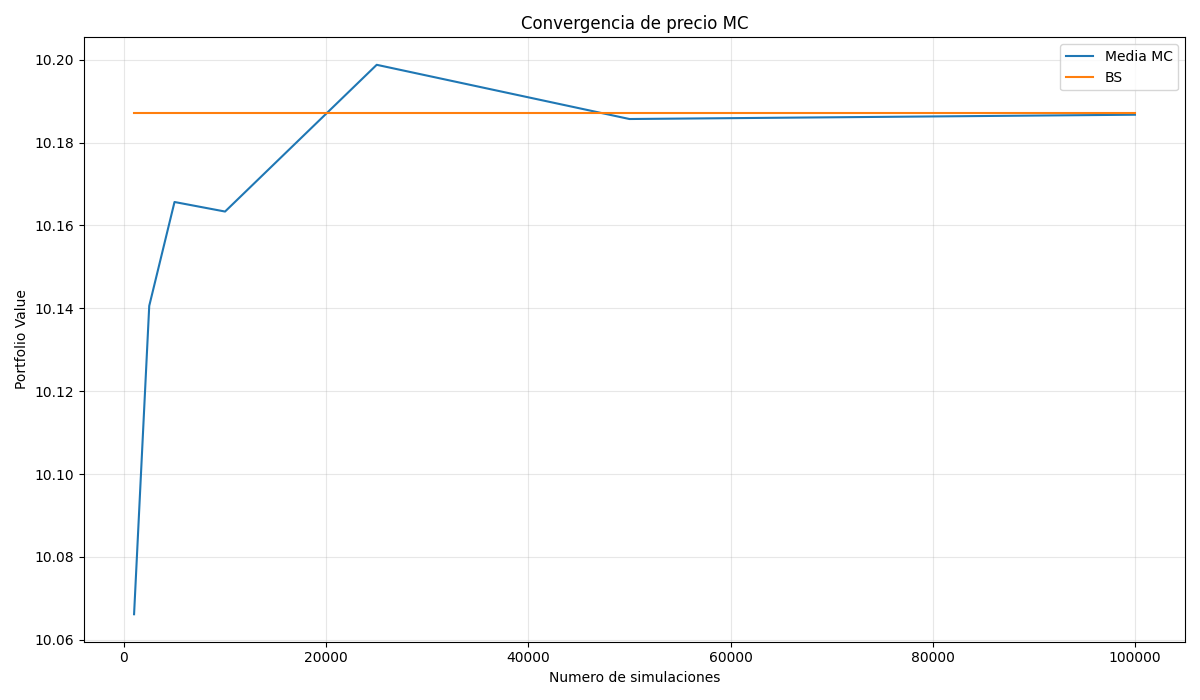

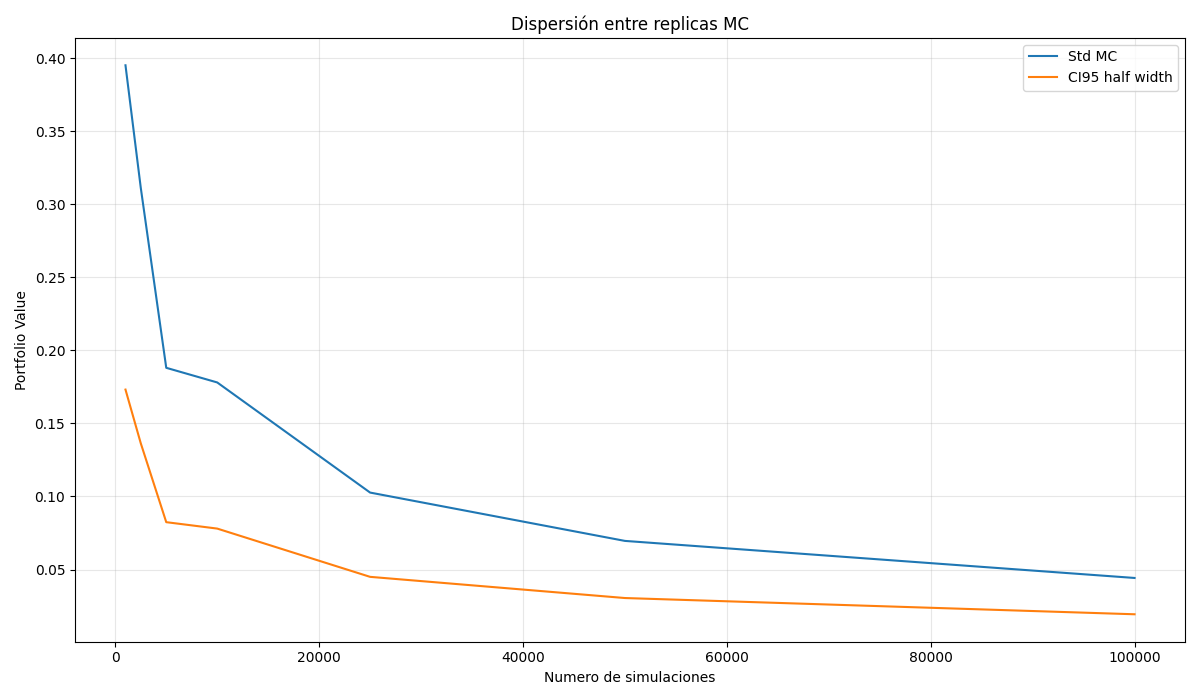

In [6]:
# Graficos de convergencia usando visualizacion predefinida
visualization_orchestrator.render_sensitivity_report(
    output_dir=VIS_DIR,
    x_range=conv_df["n_sim"].to_numpy(dtype=float),
    x_label="Numero de simulaciones",
    title="Convergencia de precio MC",
    file_name="convergencia_precio_mc.png",
    csv_name="convergencia_precio_mc.csv",
    series_by_strategy={
        "Media MC": conv_df["mean_price"].tolist(),
        "BS": [float(price_bs)] * len(conv_df),
    },
    rows=conv_df.to_dict(orient="records"),
)

visualization_orchestrator.render_sensitivity_report(
    output_dir=VIS_DIR,
    x_range=conv_df["n_sim"].to_numpy(dtype=float),
    x_label="Numero de simulaciones",
    title="Dispersión entre replicas MC",
    file_name="convergencia_dispersion_mc.png",
    csv_name="convergencia_dispersion_mc.csv",
    series_by_strategy={
        "Std MC": conv_df["std_price"].tolist(),
        "CI95 half width": conv_df["ci95_half_width"].tolist(),
    },
    rows=conv_df.to_dict(orient="records"),
)

display(Image(filename=f"{VIS_DIR}/convergencia_precio_mc.png"))
display(Image(filename=f"{VIS_DIR}/convergencia_dispersion_mc.png"))

In [7]:
# 4) Stress testing de parametros
base_iv = sigma_used

def stressed_option(base_opt, spot_mult=1.0, r_shift=0.0, vol_mult=1.0):
    opt = copy.deepcopy(base_opt)
    opt["S"] = base_opt["S"] * spot_mult
    opt["r"] = base_opt["r"] + r_shift
    sigma_stress = base_iv * vol_mult

    if base_opt["type"] == "call":
        opt["market_price"] = BlackScholesPricer.call_price(opt["S"], opt["K"], opt["T"], opt["r"], sigma_stress)
    else:
        opt["market_price"] = BlackScholesPricer.put_price(opt["S"], opt["K"], opt["T"], opt["r"], sigma_stress)
    return opt

scenarios = [
    ("Base", 1.00, 0.0000, 1.00),
    ("Spot -10%", 0.90, 0.0000, 1.00),
    ("Spot +10%", 1.10, 0.0000, 1.00),
    ("r -100 bps", 1.00, -0.0100, 1.00),
    ("r +100 bps", 1.00, 0.0100, 1.00),
    ("Vol -20%", 1.00, 0.0000, 0.80),
    ("Vol +20%", 1.00, 0.0000, 1.20),
]

stress_rows = []
for name, s_mult, r_shift, vol_mult in scenarios:
    opt_scn = stressed_option(option_data, spot_mult=s_mult, r_shift=r_shift, vol_mult=vol_mult)
    price_scn = price_option_monte_carlo(opt_scn, n_sim=MC_CFG["n_sim_greeks"], n_steps=MC_CFG["n_steps"])
    stress_rows.append(
        {
            "Escenario": name,
            "Precio": float(price_scn),
            "PnL vs Base": float(price_scn - price_mc),
        }
    )

stress_df = pd.DataFrame(stress_rows)
stress_df

,Escenario,Precio,PnL vs Base
0,Base,10.176180,0.015108
1,Spot -10%,5.157233,-5.003838
2,Spot +10%,16.949589,6.788517
3,r -100 bps,9.690190,-0.470882
4,r +100 bps,10.675767,0.514695
5,Vol -20%,8.473777,-1.687295
6,Vol +20%,11.883813,1.722742


,Escenario,Precio,PnL vs Base
0,Base,10.176180,0.015108
1,Spot -10%,5.157233,-5.003838
2,Spot +10%,16.949589,6.788517
3,r -100 bps,9.690190,-0.470882
4,r +100 bps,10.675767,0.514695
5,Vol -20%,8.473777,-1.687295
6,Vol +20%,11.883813,1.722742


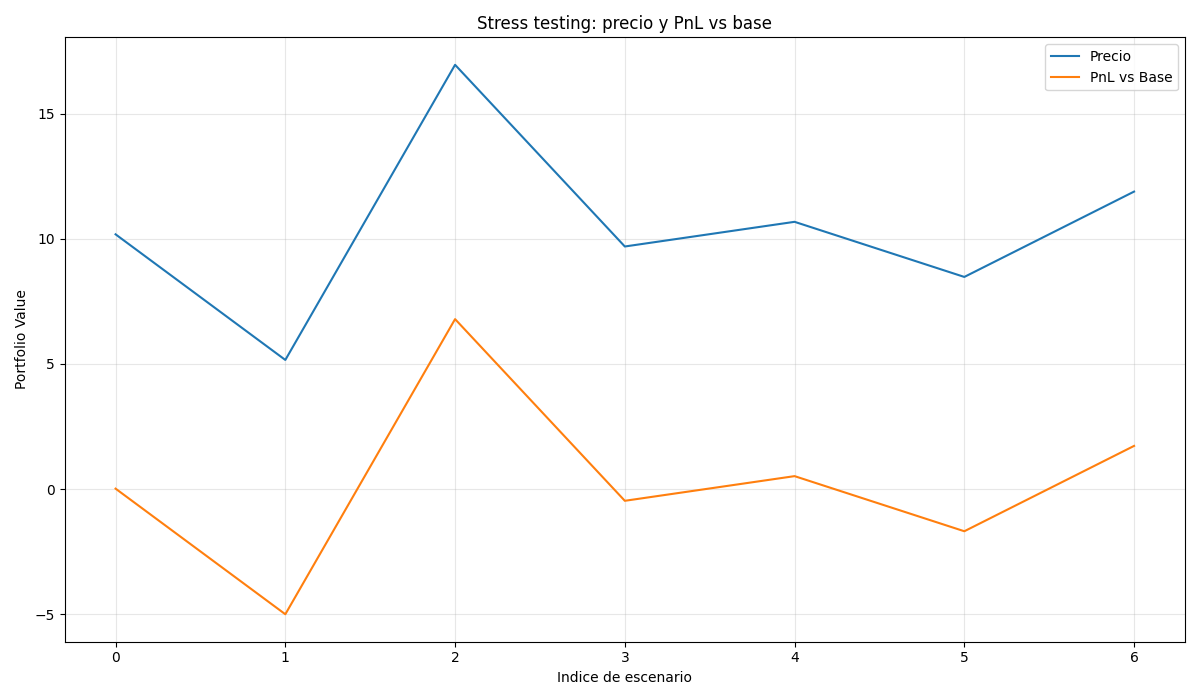

In [8]:
# Curva de stress con herramienta de visualizacion
x_stress = np.arange(len(stress_df), dtype=float)
visualization_orchestrator.render_sensitivity_report(
    output_dir=VIS_DIR,
    x_range=x_stress,
    x_label="Indice de escenario",
    title="Stress testing: precio y PnL vs base",
    file_name="stress_testing_curvas.png",
    csv_name="stress_testing_curvas.csv",
    series_by_strategy={
        "Precio": stress_df["Precio"].tolist(),
        "PnL vs Base": stress_df["PnL vs Base"].tolist(),
    },
    rows=stress_df.to_dict(orient="records"),
)

display(stress_df)
display(Image(filename=f"{VIS_DIR}/stress_testing_curvas.png"))

In [9]:
# 5) Riesgo: simulacion de PnL + VaR/ES
portfolio = [{**option_data, "qty": 25}]

risk_result = simulate_monte_carlo_portfolio_pricing(
    portfolio=portfolio,
    n_sims=MC_CFG["n_sims_risk"],
    n_steps=MC_CFG["n_steps"],
    horizon=option_data["T"],
    vol_shock_sigma=0.12,
    rho=-0.4,
)

pnl = risk_result["pnl"]
var_95, es_95 = value_at_risk_expected_shortfall(pnl, alpha=0.05)
var_99, es_99 = value_at_risk_expected_shortfall(pnl, alpha=0.01)

risk_df = pd.DataFrame(
    {
        "Metrica": ["VaR 95%", "ES 95%", "VaR 99%", "ES 99%", "Media PnL", "Std PnL"],
        "Valor": [float(var_95), float(es_95), float(var_99), float(es_99), float(pnl.mean()), float(pnl.std(ddof=1))],
    }
)
risk_df

,Metrica,Valor
0,VaR 95%,9.652272
1,ES 95%,9.824634
2,VaR 99%,9.906901
3,ES 99%,9.915955
4,Media PnL,192.807199
5,Std PnL,345.666666


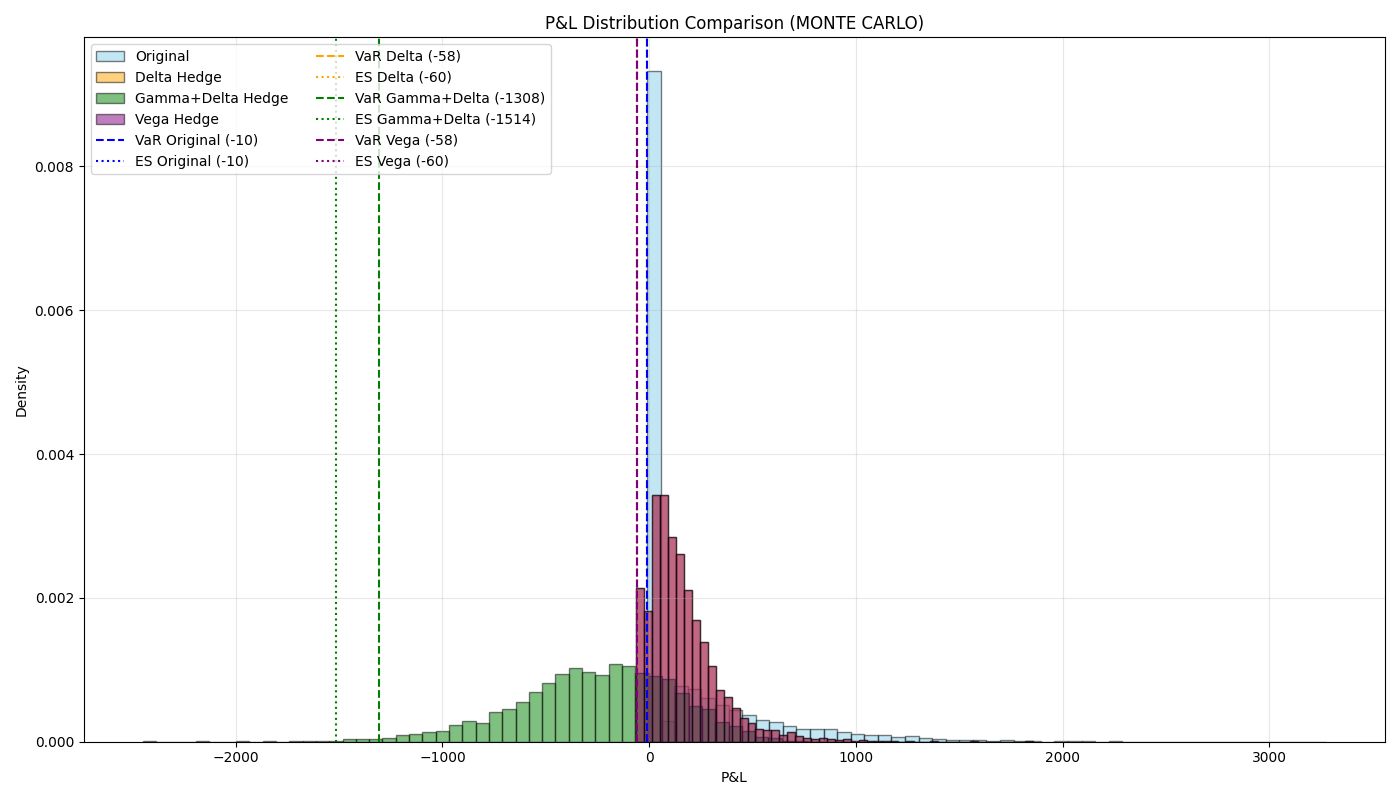

,var_delta,es_delta,var_gamma_delta,es_gamma_delta,var_vega,es_vega
0,58.036728,59.898598,1308.029833,1514.269127,58.036728,59.898598


In [10]:
# Visual de PnL con utilidades predefinidas (comparador hedging)
from portfolio import run_monte_carlo_hedging_analysis

base_value = sum(
    price_option_monte_carlo(opt, n_sim=1_000, n_steps=MC_CFG["n_steps"]) * opt["qty"]
    for opt in portfolio
)

hedging_metrics = run_monte_carlo_hedging_analysis(
    portfolio=portfolio,
    pnl_mc=pnl,
    shocks_mc=risk_result["shocks"],
    base_value=base_value,
    var_mc=var_99,
    es_mc=es_99,
    n_sim_greeks=2_000,
    n_steps=MC_CFG["n_steps"],
    simulation_horizon=option_data["T"],
    vis_dir=VIS_DIR,
)

display(Image(filename=f"{VIS_DIR}/histogram_compare_mc.png"))
pd.DataFrame([hedging_metrics])

,steps,price_binomial,error_vs_bs,error_vs_mc
0,10,9.972502,-0.214629,-0.188569
1,25,10.270723,0.083591,0.109651
2,50,10.143707,-0.043424,-0.017364
3,100,10.165391,-0.021740,0.004320
4,250,10.178428,-0.008703,0.017357
5,500,10.182779,-0.004352,0.021707
6,1000,10.184955,-0.002176,0.023883


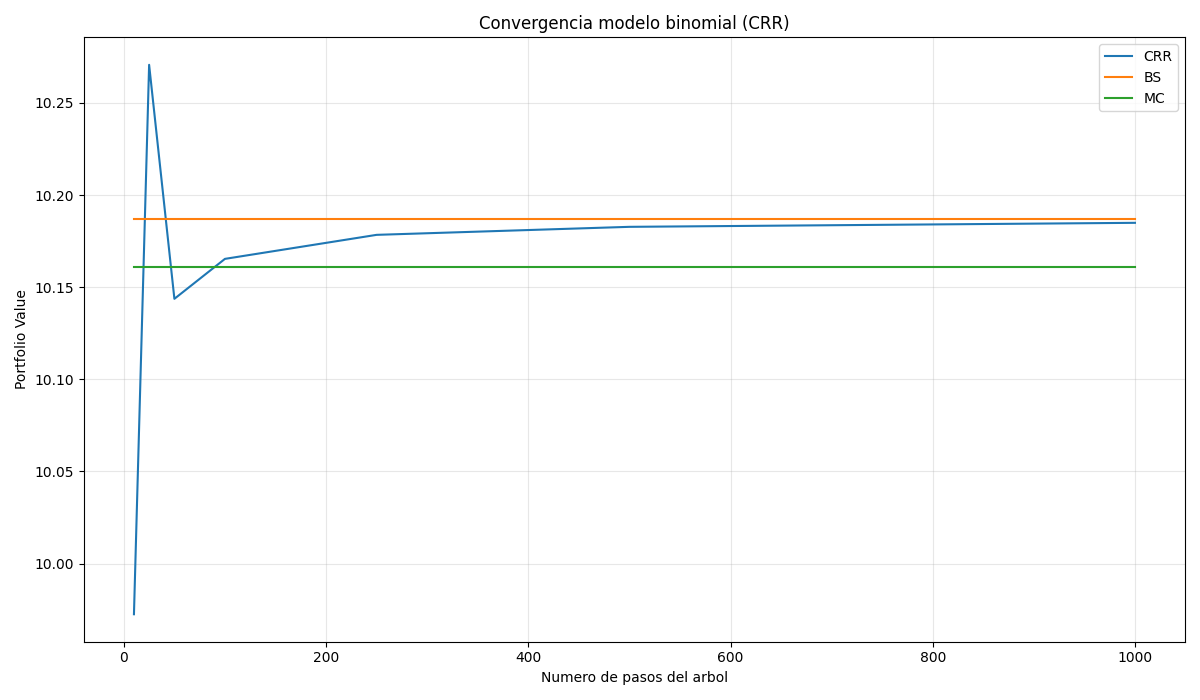

In [11]:
# Precio binomial CRR en varios pasos y convergencia
steps_grid = [10, 25, 50, 100, 250, 500, 1000]
crr_model = CoxRossRubinsteinBinomialModel()

binomial_rows = []
for steps in steps_grid:
    contract_bin = OptionContract(
        spot=S,
        strike=K,
        time_to_maturity=T,
        risk_free_rate=r,
        volatility=sigma_used,
        steps=steps,
        option_type=OptionType.from_string(opt_type),
    )
    price_bin = crr_model.price(contract_bin)
    binomial_rows.append(
        {
            "steps": steps,
            "price_binomial": float(price_bin),
            "error_vs_bs": float(price_bin - price_bs),
            "error_vs_mc": float(price_bin - price_mc),
        }
    )

binomial_df = pd.DataFrame(binomial_rows)

visualization_orchestrator.render_sensitivity_report(
    output_dir=VIS_DIR,
    x_range=binomial_df["steps"].to_numpy(dtype=float),
    x_label="Numero de pasos del arbol",
    title="Convergencia modelo binomial (CRR)",
    file_name="convergencia_binomial_crr.png",
    csv_name="convergencia_binomial_crr.csv",
    series_by_strategy={
        "CRR": binomial_df["price_binomial"].tolist(),
        "BS": [float(price_bs)] * len(binomial_df),
        "MC": [float(price_mc)] * len(binomial_df),
    },
    rows=binomial_df.to_dict(orient="records"),
)

display(binomial_df)
display(Image(filename=f"{VIS_DIR}/convergencia_binomial_crr.png"))

In [12]:
# 7) Comparativa de griegas: MC vs BS vs Binomial
def bs_greeks(spot, strike, maturity, rate, vol, option_type="call"):
    d1 = (np.log(spot / strike) + (rate + 0.5 * vol**2) * maturity) / (vol * np.sqrt(maturity))
    d2 = d1 - vol * np.sqrt(maturity)

    if option_type == "call":
        delta = stats.norm.cdf(d1)
        theta = (
            -(spot * stats.norm.pdf(d1) * vol) / (2 * np.sqrt(maturity))
            - rate * strike * np.exp(-rate * maturity) * stats.norm.cdf(d2)
        )
        rho = strike * maturity * np.exp(-rate * maturity) * stats.norm.cdf(d2)
    else:
        delta = stats.norm.cdf(d1) - 1
        theta = (
            -(spot * stats.norm.pdf(d1) * vol) / (2 * np.sqrt(maturity))
            + rate * strike * np.exp(-rate * maturity) * stats.norm.cdf(-d2)
        )
        rho = -strike * maturity * np.exp(-rate * maturity) * stats.norm.cdf(-d2)

    gamma = stats.norm.pdf(d1) / (spot * vol * np.sqrt(maturity))
    vega = spot * stats.norm.pdf(d1) * np.sqrt(maturity)

    return {
        "delta": float(delta),
        "gamma": float(gamma),
        "vega": float(vega),
        "theta": float(theta),
        "rho": float(rho),
    }


greeks_bs = bs_greeks(S, K, T, r, sigma_used, option_type=opt_type)

contract_bin_greeks = OptionContract(
    spot=S,
    strike=K,
    time_to_maturity=T,
    risk_free_rate=r,
    volatility=sigma_used,
    steps=1000,
    option_type=OptionType.from_string(opt_type),
)
greeks_bin = BinomialGreeksCalculator().calculate(contract_bin_greeks)

all_keys = ["delta", "gamma", "vega", "theta", "rho"]
greeks_compare_df = pd.DataFrame(
    {
        "Greek": all_keys,
        "MonteCarlo": [greeks_mc.get(k, np.nan) for k in all_keys],
        "BlackScholes": [greeks_bs.get(k, np.nan) for k in all_keys],
        "BinomialCRR": [greeks_bin.get(k, np.nan) for k in all_keys],
        "AbsErr_MC_vs_BS": [abs(greeks_mc.get(k, np.nan) - greeks_bs.get(k, np.nan)) for k in all_keys],
        "AbsErr_Bin_vs_BS": [abs(greeks_bin.get(k, np.nan) - greeks_bs.get(k, np.nan)) for k in all_keys],
    }
)

greeks_compare_df

,Greek,MonteCarlo,BlackScholes,BinomialCRR,AbsErr_MC_vs_BS,AbsErr_Bin_vs_BS
0,delta,0.568002,0.597300,0.597276,0.029297,0.000024
1,gamma,0.032992,0.017592,0.024471,0.015400,0.006879
2,vega,34.851800,38.701723,38.691142,3.849923,0.010581
3,theta,11.239237,-5.743475,-5.753892,16.982712,0.010418
4,rho,47.159293,49.542831,49.537247,2.383539,0.005584
